In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("All imports successful! ✅")

All imports successful! ✅


In [ ]:
#Loaded data into code its a WFDB(Waveform Database) .dat tells us raw ECG signal(Voltage), .hea(header/metadata about recording), .atr(annotations from cardiologists)

# Path to your extracted dataset folder
DATA_PATH = r"C:\GitHub Repositories\Machine-Learning-Heart-Arrythmia\main\mit-bih-arrhythmia-database-1.0.0\mit-bih-arrhythmia-database-1.0.0"

# All 48 MIT-BIH record numbers
records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

all_features = []
all_labels = []

NORMAL = ['N', 'L', 'R', 'e', 'j']

print("Loading records... this may take a minute ⏳")

for rec in records:
    try:
        record = wfdb.rdrecord(os.path.join(DATA_PATH, rec))
        annotation = wfdb.rdann(os.path.join(DATA_PATH, rec), 'atr')
        
        signal = record.p_signal[:, 0]
        beat_samples = annotation.sample
        beat_symbols = annotation.symbol
        
        for i, (sample, symbol) in enumerate(zip(beat_samples, beat_symbols)):
            start = sample - 90
            end = sample + 90
            if start < 0 or end > len(signal):
                continue
            window = signal[start:end]
            all_features.append(window)
            label = 0 if symbol in NORMAL else 1
            all_labels.append(label)
    except:
        print(f"Skipping record {rec}")
        continue

X = np.array(all_features)
y = np.array(all_labels)

print(f"\nTotal beats loaded: {len(X)}")
print(f"Normal beats:   {sum(y==0)}")
print(f"Abnormal beats: {sum(y==1)}")

Loading records... this may take a minute ⏳

Total beats loaded: 112579
Normal beats:   90608
Abnormal beats: 21971


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 90063
Testing samples:  22516


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled! ✅")

Scaled! ✅


In [ ]:
#PCA chooses/simplifies what features to use on its own, you will see some examples its chosen on the bottom code graphs

pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

variance_kept = sum(pca.explained_variance_ratio_) * 100
print(f"Variance kept: {variance_kept:.1f}%")

Variance kept: 99.7%


In [ ]:
#SVM used to choose random sets in data to test and train so 20k beats were chosen randomly, issue with SVM is it doesnt work well with large datasets since its 
#slow so you choose a smaller sample size but this can cause the model to miss some abnormal patterns

SAMPLE_SIZE = 20000
idx = np.random.choice(len(X_train_pca), SAMPLE_SIZE, replace=False)
X_sample = X_train_pca[idx]
y_sample = y_train[idx]

print("Training SVM... ⏳")
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_sample, y_sample)
print("Done! ✅")

Training SVM... ⏳
Done! ✅


In [ ]:
#Classification report how to read - Precision is how many times it guessed correctly, Recall is how many actually abnormal did it find
#F1 score is the average of the recall and precision and support is number of classified beats in test data

y_pred = svm.predict(X_test_pca)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.97     18122
    Abnormal       0.97      0.76      0.85      4394

    accuracy                           0.95     22516
   macro avg       0.96      0.88      0.91     22516
weighted avg       0.95      0.95      0.95     22516



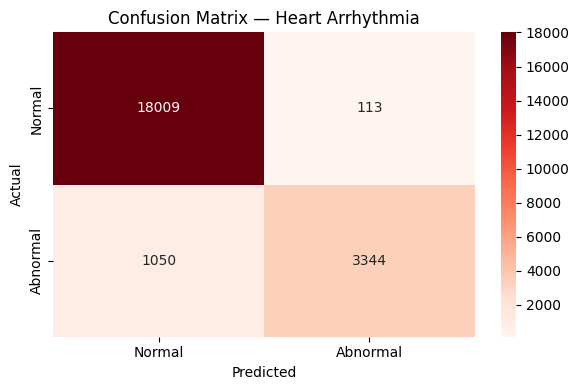

In [ ]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title("Confusion Matrix — Heart Arrhythmia")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
#Retrain aiming to tradeoff more false positives than false negatives- safer for a medical standpoint

from sklearn.utils import resample

# Balance the classes by upsampling abnormal beats
idx_normal = np.where(y_train == 0)[0]
idx_abnormal = np.where(y_train == 1)[0]

# Sample equally from both
n = 10000
idx_n = np.random.choice(idx_normal, n, replace=False)
idx_a = np.random.choice(idx_abnormal, n, replace=True)

X_balanced = np.vstack([X_train_pca[idx_n], X_train_pca[idx_a]])
y_balanced = np.hstack([y_train[idx_n], y_train[idx_a]])

print("Retraining with balanced classes... ⏳")
svm2 = SVC(kernel='rbf', C=10.0, class_weight='balanced', random_state=42)
svm2.fit(X_balanced, y_balanced)
print("Done! ✅")

Retraining with balanced classes... ⏳
Done! ✅


=== Improved Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     18122
    Abnormal       0.89      0.94      0.92      4394

    accuracy                           0.97     22516
   macro avg       0.94      0.96      0.95     22516
weighted avg       0.97      0.97      0.97     22516



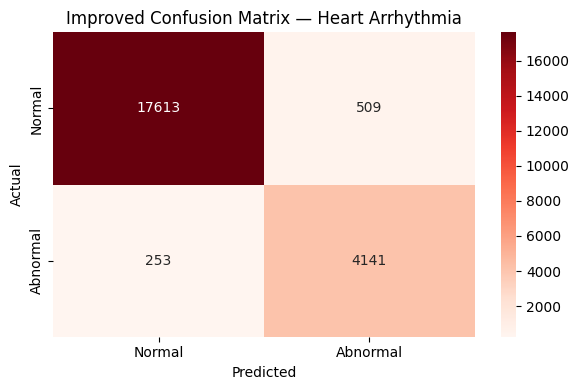

In [ ]:
#Model after retraining

y_pred2 = svm2.predict(X_test_pca)

print("=== Improved Classification Report ===")
print(classification_report(y_test, y_pred2, target_names=['Normal', 'Abnormal']))

cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title("Improved Confusion Matrix — Heart Arrhythmia")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

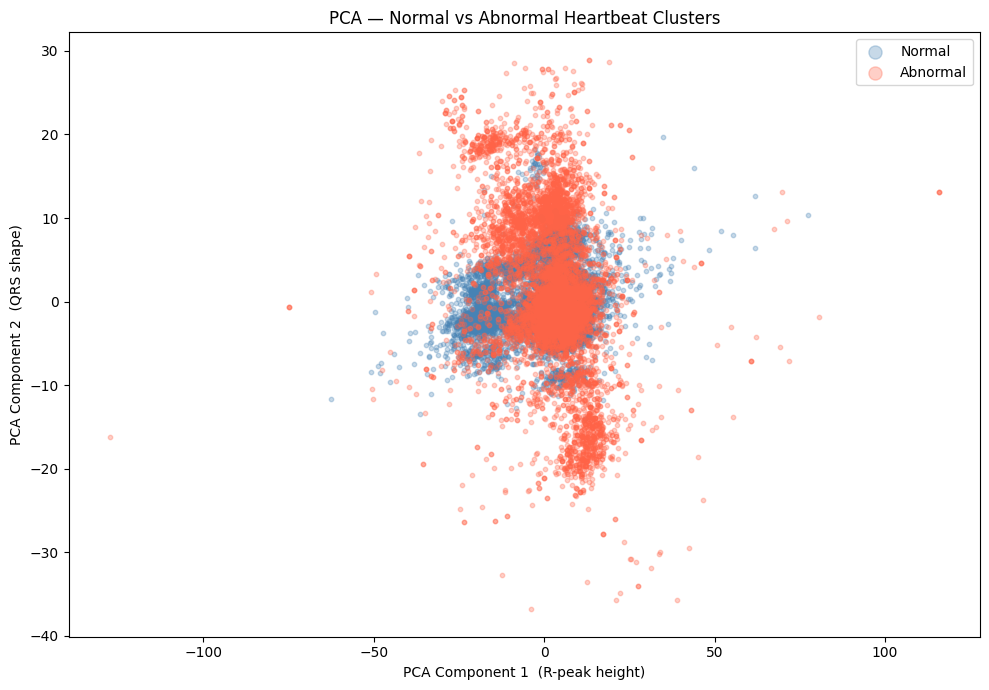

In [ ]:
#How the data points look normal vs abnormal we see that abnormal is significantly more spread out than normal meaning more feature variance tends to mean beat 
#is abnormal this is plotted on a 2D scale

plt.figure(figsize=(10, 7))

colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Normal', 1: 'Abnormal'}

for label in [0, 1]:
    mask = y_balanced == label
    plt.scatter(X_balanced[mask, 0], X_balanced[mask, 1],
                c=colors[label], label=labels[label],
                alpha=0.3, s=10)

plt.title("PCA — Normal vs Abnormal Heartbeat Clusters")
plt.xlabel("PCA Component 1  (R-peak height)")
plt.ylabel("PCA Component 2  (QRS shape)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

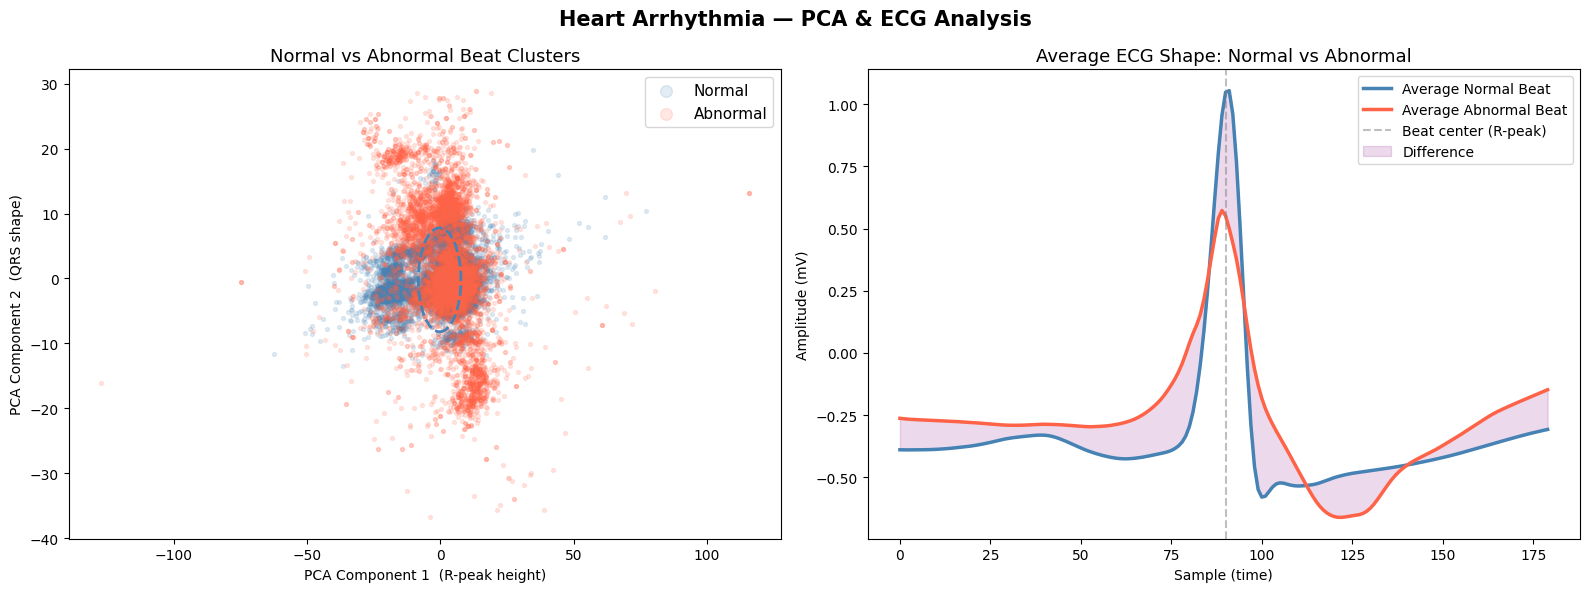

In [ ]:
#Major point here is that the average pulse size of a normal heart beat gives a 1mV reading as opposed to the average abnormal heart beat which is .6mV
#This is very helpful for our modl as this feature is easy to distinguish

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Density plot (cleaner than scatter) ---
ax1 = axes[0]
for label, color, name in zip([0,1], ['steelblue','tomato'], ['Normal','Abnormal']):
    mask = y_balanced == label
    ax1.scatter(X_balanced[mask, 0], X_balanced[mask, 1],
                c=color, label=name, alpha=0.15, s=8)

# Draw a circle around the normal cluster
circle = plt.Circle((X_balanced[y_balanced==0, 0].mean(),
                      X_balanced[y_balanced==0, 1].mean()),
                      8, color='steelblue', fill=False, linewidth=2, linestyle='--')
ax1.add_patch(circle)
ax1.set_title("Normal vs Abnormal Beat Clusters", fontsize=13)
ax1.set_xlabel("PCA Component 1  (R-peak height)")
ax1.set_ylabel("PCA Component 2  (QRS shape)")
ax1.legend(markerscale=3, fontsize=11)

# --- Plot 2: Show average beat shape for Normal vs Abnormal ---
ax2 = axes[1]
normal_beats = X_train[y_train == 0]
abnormal_beats = X_train[y_train == 1]

mean_normal   = normal_beats.mean(axis=0)
mean_abnormal = abnormal_beats.mean(axis=0)

time = np.arange(180)
ax2.plot(time, mean_normal,   color='steelblue', linewidth=2.5, label='Average Normal Beat')
ax2.plot(time, mean_abnormal, color='tomato',    linewidth=2.5, label='Average Abnormal Beat')
ax2.axvline(x=90, color='gray', linestyle='--', alpha=0.5, label='Beat center (R-peak)')
ax2.fill_between(time, mean_normal, mean_abnormal, alpha=0.15, color='purple', label='Difference')
ax2.set_title("Average ECG Shape: Normal vs Abnormal", fontsize=13)
ax2.set_xlabel("Sample (time)")
ax2.set_ylabel("Amplitude (mV)")
ax2.legend(fontsize=10)

plt.suptitle("Heart Arrhythmia — PCA & ECG Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

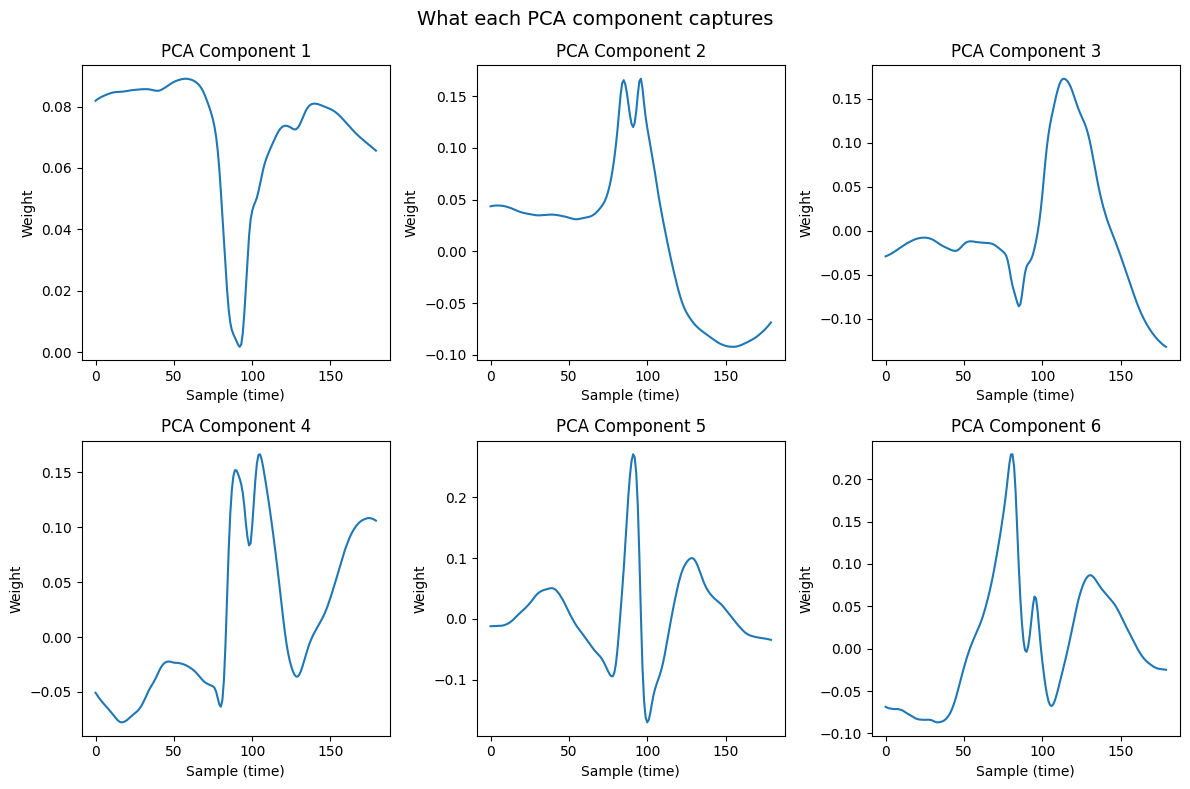

In [ ]:

#Understanding some features from the PCA feature decision making from the 180 beat/features down to 30 with 99.7% variance kept 
#Patterns it looks for comp1. large dip, comp2. double spike, comp3. mini drop then spike, etc...
plt.figure(figsize=(12, 8))
for i in range(6):  # Show first 6 components
    plt.subplot(2, 3, i+1)
    plt.plot(pca.components_[i])
    plt.title(f"PCA Component {i+1}")
    plt.xlabel("Sample (time)")
    plt.ylabel("Weight")
plt.suptitle("What each PCA component captures", fontsize=14)
plt.tight_layout()
plt.show()